In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

**Imports and Global Configuration**

This cell sets up the environment and defines the device (CPU/GPU).

In [ ]:
import torch
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import json
import os

# Setting up device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


**Data Loading and Preprocessing**

We define the transforms and split the data. Note the use of .dataset.classes to avoid the AttributeError.

In [ ]:
# Transformations with ImageNet normalization
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    # Adding this line for Standard ImageNet normalization
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Loading Dataset
data_path = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset//New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
full_dataset = datasets.ImageFolder(data_path, transform=transform)

# Splitting 80/20
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_data, val_data = random_split(full_dataset, [train_size, val_size])

# Dataloaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data, batch_size=32, num_workers=2)

# Global variables for model construction
class_names = full_dataset.classes
num_classes = len(class_names)

print(f"Total Classes: {num_classes}")
print(f"Training images: {len(train_data)}, Validation images: {len(val_data)}")

Total Classes: 38
Training images: 56236, Validation images: 14059


**Check Class Distribution**

--- Class Distribution in Training Set ---
Class 0 (Apple___Apple_scab): 1637 images
Class 1 (Apple___Black_rot): 1578 images
Class 2 (Apple___Cedar_apple_rust): 1394 images
Class 3 (Apple___healthy): 1618 images
Class 4 (Blueberry___healthy): 1446 images
Class 5 (Cherry_(including_sour)___Powdery_mildew): 1354 images
Class 6 (Cherry_(including_sour)___healthy): 1450 images
Class 7 (Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot): 1333 images
Class 8 (Corn_(maize)___Common_rust_): 1501 images
Class 9 (Corn_(maize)___Northern_Leaf_Blight): 1544 images
Class 10 (Corn_(maize)___healthy): 1479 images
Class 11 (Grape___Black_rot): 1493 images
Class 12 (Grape___Esca_(Black_Measles)): 1536 images
Class 13 (Grape___Leaf_blight_(Isariopsis_Leaf_Spot)): 1370 images
Class 14 (Grape___healthy): 1344 images
Class 15 (Orange___Haunglongbing_(Citrus_greening)): 1633 images
Class 16 (Peach___Bacterial_spot): 1486 images
Class 17 (Peach___healthy): 1405 images
Class 18 (Pepper,_bell___Bacterial_spo

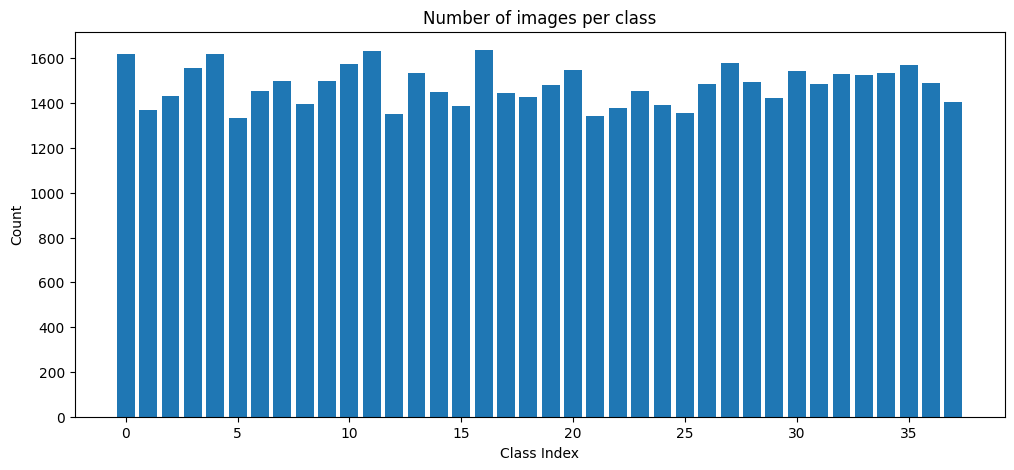

In [ ]:
from collections import Counter

# Counting labels in the training subset
train_indices = train_data.indices
# Accessing full_dataset targets through the subset's reference
train_labels = [train_data.dataset.targets[i] for i in train_indices]
counts = Counter(train_labels)

print("--- Class Distribution in Training Set ---")
for idx, count in sorted(counts.items()):
    # Using .dataset.classes to get the correct names
    print(f"Class {idx} ({train_data.dataset.classes[idx]}): {count} images")

# Visual check
plt.figure(figsize=(12, 5))
plt.bar(range(len(counts)), list(counts.values()))
plt.title("Number of images per class")
plt.xlabel("Class Index")
plt.ylabel("Count")
plt.show()

**The Training Engine Function**

This function is a reusable tool that saves files directly to the Kaggle working directory.

In [ ]:
def train_and_save_model(model, model_name, epochs=10):
    print(f"\n--- Starting Training: {model_name} ---")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    # ADDING 'train_acc' to the history dictionary
    history = {"loss": [], "accuracy": [], "train_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # CALCULATING TRAINING ACCURACY
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        # Validation Phase
        model.eval()
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        # Saving metrics
        epoch_loss = running_loss / len(train_loader)
        epoch_val_acc = 100 * correct_val / total_val
        epoch_train_acc = 100 * correct_train / total_train

        history["loss"].append(epoch_loss)
        history["accuracy"].append(epoch_val_acc)
        history["train_acc"].append(epoch_train_acc)

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")

    torch.save(model.state_dict(), f"/kaggle/working/{model_name}_final.pth")
    return history

**Training ResNet18**

Running this cell to train the first model. It will clear its own memory when finished.

In [ ]:
# Initializing ResNet18
resnet = models.resnet18(weights='DEFAULT')
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
resnet = resnet.to(device)

# Train and Save
resnet_results = train_and_save_model(resnet, "ResNet18", epochs=10)

# Free up GPU memory for the next model
del resnet
torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]



--- Starting Training: ResNet18 ---
Epoch [1/10] Loss: 0.1842 | Train Acc: 95.99% | Val Acc: 97.92%
Epoch [2/10] Loss: 0.0345 | Train Acc: 99.03% | Val Acc: 98.19%
Epoch [3/10] Loss: 0.0251 | Train Acc: 99.27% | Val Acc: 99.04%
Epoch [4/10] Loss: 0.0220 | Train Acc: 99.32% | Val Acc: 99.12%
Epoch [5/10] Loss: 0.0175 | Train Acc: 99.47% | Val Acc: 99.34%
Epoch [6/10] Loss: 0.0162 | Train Acc: 99.52% | Val Acc: 99.31%
Epoch [7/10] Loss: 0.0140 | Train Acc: 99.56% | Val Acc: 99.35%
Epoch [8/10] Loss: 0.0125 | Train Acc: 99.64% | Val Acc: 99.71%
Epoch [9/10] Loss: 0.0112 | Train Acc: 99.69% | Val Acc: 99.69%
Epoch [10/10] Loss: 0.0121 | Train Acc: 99.64% | Val Acc: 99.54%


**Train EfficientNet-B0**

Running this cell once ResNet18 is complete.

In [ ]:
# Initializing EfficientNet-B0
effnet = models.efficientnet_b0(weights='DEFAULT')
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, num_classes)
effnet = effnet.to(device)

# Train and Save
effnet_results = train_and_save_model(effnet, "EfficientNet", epochs=10)

# Free up GPU memory
del effnet
torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 127MB/s] 



--- Starting Training: EfficientNet ---
Epoch [1/10] Loss: 0.3315 | Train Acc: 93.43% | Val Acc: 99.25%
Epoch [2/10] Loss: 0.0323 | Train Acc: 99.06% | Val Acc: 99.65%
Epoch [3/10] Loss: 0.0213 | Train Acc: 99.37% | Val Acc: 99.64%
Epoch [4/10] Loss: 0.0149 | Train Acc: 99.54% | Val Acc: 99.67%
Epoch [5/10] Loss: 0.0120 | Train Acc: 99.64% | Val Acc: 99.66%
Epoch [6/10] Loss: 0.0104 | Train Acc: 99.68% | Val Acc: 99.83%
Epoch [7/10] Loss: 0.0087 | Train Acc: 99.76% | Val Acc: 99.81%
Epoch [8/10] Loss: 0.0077 | Train Acc: 99.77% | Val Acc: 99.85%
Epoch [9/10] Loss: 0.0069 | Train Acc: 99.81% | Val Acc: 99.82%
Epoch [10/10] Loss: 0.0062 | Train Acc: 99.80% | Val Acc: 99.82%


**Comparison of Results**

This cell generates a visual report of how both models performed.

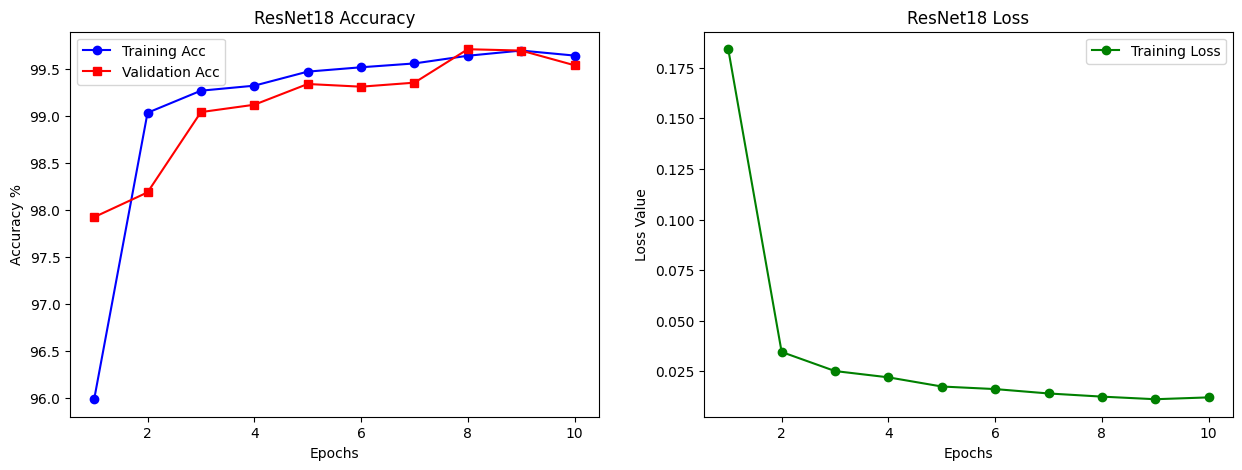

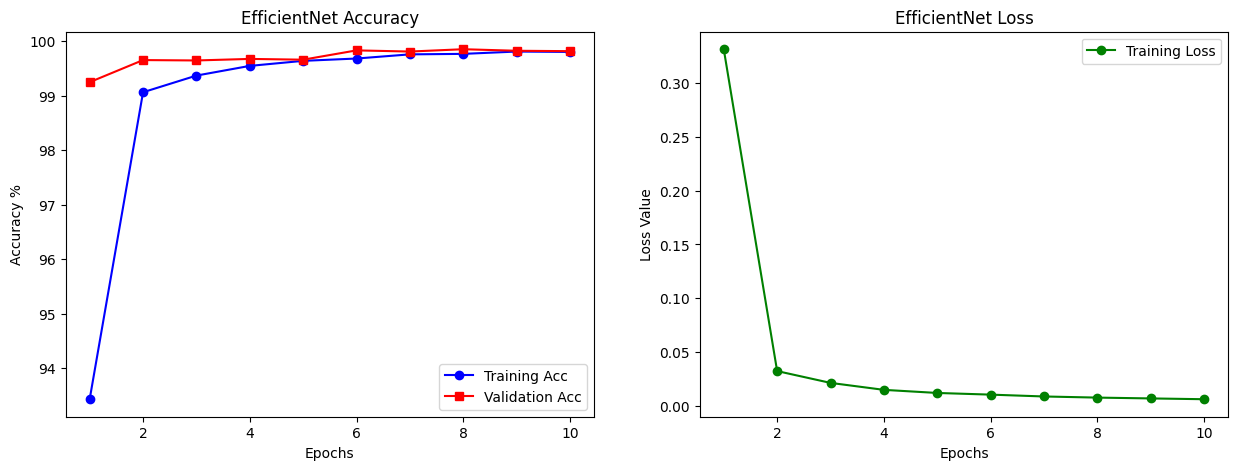

In [ ]:
def plot_learning_curves(history, model_name):
    epochs = range(1, len(history['accuracy']) + 1)

    plt.figure(figsize=(15, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_acc'], 'b-o', label='Training Acc')
    plt.plot(epochs, history['accuracy'], 'r-s', label='Validation Acc')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy %')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['loss'], 'g-o', label='Training Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend()

    plt.show()

# Execute plots
plot_learning_curves(resnet_results, "ResNet18")
plot_learning_curves(effnet_results, "EfficientNet")

**The Scanner Function**

Add this as a new code cell. It defines the logic for loading your saved weights and processing a single image.

In [ ]:
from PIL import Image

def predict_plant_disease(image_path, model_path, model_type="resnet"):
    """
    Real-time scanner function to predict disease from a single image.
    """
    # 1. Recreate the architecture using num_classes from your dataset
    if model_type == "resnet":
        model = models.resnet18()
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    else:
        model = models.efficientnet_b0()
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    # 2. Load the trained weights from the /working/ directory
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    # 3. Process the image using the same transforms as training
    img = Image.open(image_path).convert('RGB')
    img_t = transform(img).unsqueeze(0).to(device)

    # 4. Perform Inference
    with torch.no_grad():
        outputs = model(img_t)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        confidence, index = torch.max(probabilities, 0)

    result = class_names[index.item()]
    return result, confidence.item()

**Execution (Test the Scanner)**

Add this as the final code cell. It allows you to pick a specific image to test the model's accuracy immediately.

In [ ]:
# Path to a test image from the dataset or an uploaded file
test_image_path = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/AppleCedarRust1.JPG"

# Test the ResNet18 model
try:
    label, conf = predict_plant_disease(test_image_path, "/kaggle/working/ResNet18_final.pth", "resnet")
    print(f"--- Scanner Result ---")
    print(f"Predicted Disease: {label}")
    print(f"Confidence: {conf*100:.2f}%")
except FileNotFoundError:
    print("Files not found. Ensure training has finished and saved 'ResNet18_final.pth'.")

--- Scanner Result ---
Predicted Disease: Apple___Cedar_apple_rust
Confidence: 100.00%
